# 01 — Preprocessing & Data Quality
**Scientific question:** *Is the relationship between CO₂ emissions and surface temperature warming uniform across world regions, or do some regions warm faster despite emitting less?*

**Datasets used:**
1. OWID CO₂ data — emissions, GDP, population, energy
2. NASA GISS — global surface temperature anomalies
3. EPA / CSIRO — global mean sea level rise
4. EMDAT — natural disaster frequency

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid')
print('Libraries loaded ✓')

Libraries loaded ✓


## 2. Load Raw Data

In [2]:
# ── 1. OWID CO₂ dataset ──────────────────────────────────────────────────────
owid = pd.read_csv('/kaggle/input/datasets/maryemteyeb/prgrmtion-math-project/owid-co2-data.csv')
print(f'OWID shape: {owid.shape}')
print(owid.dtypes)
owid.head(3)

OWID shape: (50411, 79)
country                         object
year                             int64
iso_code                        object
population                     float64
gdp                            float64
                                ...   
temperature_change_from_n2o    float64
total_ghg                      float64
total_ghg_excluding_lucf       float64
trade_co2                      float64
trade_co2_share                float64
Length: 79, dtype: object


,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,co2_including_luc_growth_prct,co2_including_luc_per_capita,co2_including_luc_per_gdp,co2_including_luc_per_unit_energy,co2_per_capita,co2_per_gdp,co2_per_unit_energy,coal_co2,coal_co2_per_capita,consumption_co2,consumption_co2_per_capita,consumption_co2_per_gdp,cumulative_cement_co2,...,share_global_co2_including_luc,share_global_coal_co2,share_global_cumulative_cement_co2,share_global_cumulative_co2,share_global_cumulative_co2_including_luc,share_global_cumulative_coal_co2,share_global_cumulative_flaring_co2,share_global_cumulative_gas_co2,share_global_cumulative_luc_co2,share_global_cumulative_oil_co2,share_global_cumulative_other_co2,share_global_flaring_co2,share_global_gas_co2,share_global_luc_co2,share_global_oil_co2,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0000,NaN,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# ── 2. NASA GISS temperature anomalies ───────────────────────────────────────
# First 2 rows are header/units — skip them
nasa_raw = pd.read_csv(
    '/kaggle/input/datasets/maryemteyeb/prgrmtion-math-project/GLB.TsdSST.csv',
    skiprows=1
)
print(f'NASA raw shape: {nasa_raw.shape}')
print(nasa_raw.columns.tolist())
nasa_raw.head(3)

NASA raw shape: (147, 19)
['Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'J-D', 'D-N', 'DJF', 'MAM', 'JJA', 'SON']


,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
0,1880,-0.1900,-0.2500,-0.0900,-.17,-.10,-.21,-.19,-.10,-.15,-.23,-.22,-.19,-.17,***,***,-.12,-.17,-.20
1,1881,-0.1900,-0.1500,0.0300,.04,.07,-.18,.01,-.03,-.15,-.21,-.18,-.07,-.08,-.09,-.18,.05,-.07,-.18
2,1882,0.1600,0.1400,0.0500,-.16,-.14,-.22,-.16,-.07,-.14,-.23,-.17,-.36,-.11,-.08,.08,-.08,-.15,-.18


In [4]:
# ── 3. Sea level rise ────────────────────────────────────────────────────────
sea = pd.read_csv('/kaggle/input/datasets/maryemteyeb/prgrmtion-math-project/epa-sea-level.csv')
print(f'Sea level shape: {sea.shape}')
print(sea.dtypes)
sea.head(3)

Sea level shape: (144, 5)
Year                          int64
CSIRO Adjusted Sea Level    float64
Lower Error Bound           float64
Upper Error Bound           float64
NOAA Adjusted Sea Level     float64
dtype: object


,Year,CSIRO Adjusted Sea Level,Lower Error Bound,Upper Error Bound,NOAA Adjusted Sea Level
0,1880,0.0000,-0.9528,0.9528,NaN
1,1881,0.2205,-0.7323,1.1732,NaN
2,1882,-0.4409,-1.3465,0.4646,NaN


In [5]:
# ── 4. Natural disasters ─────────────────────────────────────────────────────
disasters = pd.read_csv(
    '/kaggle/input/datasets/maryemteyeb/prgrmtion-math-project/Natural disasters from 1900 to 2019 - EMDAT (2020).csv'
)
print(f'Disasters shape: {disasters.shape}')
print(disasters.columns.tolist())
disasters.head(3)

Disasters shape: (837, 9)
['Entity', 'Year', 'Number of disasters (EMDAT (2019))', 'Total deaths (EMDAT (2019))', 'Injured (EMDAT (2019))', 'Affected (EMDAT (2019))', 'Homeless (EMDAT (2019))', 'Total affected (EMDAT (2019))', 'Total economic damage (EMDAT (2019))']


,Entity,Year,Number of disasters (EMDAT (2019)),Total deaths (EMDAT (2019)),Injured (EMDAT (2019)),Affected (EMDAT (2019)),Homeless (EMDAT (2019)),Total affected (EMDAT (2019)),Total economic damage (EMDAT (2019))
0,All natural disasters,1900,5,1267330.0000,0.0000,0.0000,0.0000,0.0000,30000000.0000
1,All natural disasters,1901,2,18.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,All natural disasters,1902,9,46037.0000,0.0000,0.0000,0.0000,0.0000,0.0000


## 3. Data Quality Assessment

In [6]:
# ── Missing values rate per variable ────────────────────────────────────────
def missing_report(df, name):
    missing = df.isnull().sum()
    pct = (missing / len(df) * 100).round(2)
    report = pd.DataFrame({'missing_count': missing, 'missing_%': pct})
    report = report[report['missing_count'] > 0].sort_values('missing_%', ascending=False)
    print(f'\n── {name} ── {len(df)} rows, {len(df.columns)} cols')
    print(f'  Variables with missing data: {len(report)}/{len(df.columns)}')
    return report

owid_missing   = missing_report(owid,      'OWID CO₂')
nasa_missing   = missing_report(nasa_raw,  'NASA GISS')
sea_missing    = missing_report(sea,       'Sea Level')
dis_missing    = missing_report(disasters, 'Disasters')

print('\nTop 10 missing columns in OWID:')
print(owid_missing.head(10))


── OWID CO₂ ── 50411 rows, 79 cols
  Variables with missing data: 77/79

── NASA GISS ── 147 rows, 19 cols
  Variables with missing data: 0/19

── Sea Level ── 144 rows, 5 cols
  Variables with missing data: 4/5

── Disasters ── 837 rows, 9 cols
  Variables with missing data: 6/9

Top 10 missing columns in OWID:
                                   missing_count  missing_%
share_global_cumulative_other_co2          48241    95.7000
share_global_other_co2                     48241    95.7000
other_co2_per_capita                       47752    94.7300
cumulative_other_co2                       47157    93.5500
other_industry_co2                         47157    93.5500
consumption_co2_per_gdp                    45963    91.1800
consumption_co2_per_capita                 45768    90.7900
trade_co2                                  45699    90.6500
trade_co2_share                            45699    90.6500
consumption_co2                            45358    89.9800


In [7]:
# ── Statistical summary (before cleaning) ───────────────────────────────────
key_cols = ['co2', 'co2_per_capita', 'temperature_change_from_co2',
            'population', 'gdp', 'share_global_co2']
key_cols_present = [c for c in key_cols if c in owid.columns]
print('OWID key variables — summary before cleaning:')
owid[key_cols_present].describe().round(3)

OWID key variables — summary before cleaning:


,co2,co2_per_capita,temperature_change_from_co2,population,gdp,share_global_co2
count,29384.0000,26509.0000,41238.0000,41167.0000,15251.0000,27563.0000
mean,420.2270,3.8210,0.0080,60174525.1720,330049485119.5140,5.3700
std,1972.0920,14.3130,0.0460,330843317.8990,3086383264219.9058,18.7350
min,0.0000,0.0000,-0.0000,215.0000,49980000.0000,0.0000
25%,0.3810,0.1710,0.0000,327214.0000,7874037500.0000,0.0040
50%,5.0810,1.0230,0.0000,2291594.0000,27438613750.0000,0.0530
75%,53.6560,4.3270,0.0010,9986553.0000,121262743747.5000,0.5750
max,38598.5780,782.7430,1.2160,8161972574.0000,130112562171124.9844,100.0000


## 4. Cleaning Each Dataset

In [8]:
# ── Clean OWID ───────────────────────────────────────────────────────────────
# Keep only actual countries (remove aggregates like 'World', 'Asia', etc.)
# OWID uses iso_code NaN for aggregates
owid_clean = owid.dropna(subset=['iso_code']).copy()

# Keep from 1980 onwards (our question is since 1980)
owid_clean = owid_clean[owid_clean['year'] >= 1980]

# Select the columns we'll actually use
cols_to_keep = [
    'country', 'iso_code', 'year', 'population', 'gdp',
    'co2', 'co2_per_capita', 'share_global_co2',
    'coal_co2', 'oil_co2', 'gas_co2', 'cement_co2',
    'co2_growth_prct', 'cumulative_co2',
    'temperature_change_from_co2', 'energy_per_capita'
]
cols_to_keep = [c for c in cols_to_keep if c in owid_clean.columns]
owid_clean = owid_clean[cols_to_keep]

# Rename for clarity
owid_clean = owid_clean.rename(columns={'year': 'Year', 'country': 'Entity', 'iso_code': 'Code'})

# Outlier detection on co2 using IQR
Q1 = owid_clean['co2'].quantile(0.25)
Q3 = owid_clean['co2'].quantile(0.75)
IQR = Q3 - Q1
outliers = owid_clean[owid_clean['co2'] > Q3 + 3 * IQR]
print(f'Potential CO₂ outliers (>Q3 + 3×IQR): {len(outliers)} rows')
print(outliers[['Entity', 'Year', 'co2']].head(10))

print(f'\nOWID clean shape: {owid_clean.shape}')
owid_clean.head(3)

Potential CO₂ outliers (>Q3 + 3×IQR): 1065 rows
         Entity  Year      co2
1073    Algeria  2023 202.8466
3634  Australia  1980 204.3702
3635  Australia  1981 213.8099
3636  Australia  1982 218.0009
3637  Australia  1983 207.6454
3638  Australia  1984 217.5146
3639  Australia  1985 224.5574
3640  Australia  1986 224.0403
3641  Australia  1987 234.5983
3642  Australia  1988 240.7370

OWID clean shape: (9810, 16)


,Entity,Code,Year,population,gdp,co2,co2_per_capita,share_global_co2,coal_co2,oil_co2,gas_co2,cement_co2,co2_growth_prct,cumulative_co2,temperature_change_from_co2,energy_per_capita
230,Afghanistan,AFG,1980,13169313.0000,15329836000.0000,1.7563,0.1334,0.0090,0.3158,0.9253,0.1873,0.0233,-21.3392,31.7940,0.0005,481.2086
231,Afghanistan,AFG,1981,11937586.0000,15645344000.0000,1.9785,0.1657,0.0105,0.3334,1.0149,0.3041,0.0329,12.6494,33.7724,0.0005,610.6390
232,Afghanistan,AFG,1982,10991380.0000,15980410000.0000,2.0946,0.1906,0.0112,0.3847,0.9929,0.3957,0.0391,5.8691,35.8670,0.0005,717.7664


In [9]:
# ── Clean NASA GISS ──────────────────────────────────────────────────────────
# The file has months (Jan-Dec) + seasonal columns + annual mean
# We want just Year and the annual mean (column 'J-D')
nasa = nasa_raw[['Year', 'J-D']].copy()
nasa.columns = ['Year', 'temp_anomaly']

# Convert to numeric (some entries may be '***' for missing)
nasa['temp_anomaly'] = pd.to_numeric(nasa['temp_anomaly'], errors='coerce')
nasa['Year'] = pd.to_numeric(nasa['Year'], errors='coerce')

# Drop rows with missing anomaly
before = len(nasa)
nasa = nasa.dropna()
print(f'NASA: dropped {before - len(nasa)} rows with missing anomaly')

# Filter 1980+
nasa = nasa[nasa['Year'] >= 1980].reset_index(drop=True)

# Anomaly is in units of 0.01°C in some versions — check scale
if nasa['temp_anomaly'].abs().max() > 10:
    nasa['temp_anomaly'] = nasa['temp_anomaly'] / 100
    print('Rescaled temp_anomaly from 0.01°C units to °C')

print(f'NASA clean shape: {nasa.shape}')
print(nasa.describe())
nasa.head(3)

NASA: dropped 1 rows with missing anomaly
NASA clean shape: (46, 2)
           Year  temp_anomaly
count   46.0000       46.0000
mean  2002.5000        0.5778
std     13.4226        0.2987
min   1980.0000        0.1200
25%   1991.2500        0.3225
50%   2002.5000        0.5750
75%   2013.7500        0.7425
max   2025.0000        1.2800


,Year,temp_anomaly
0,1980,0.2600
1,1981,0.3200
2,1982,0.1400


In [10]:
# ── Clean Sea Level ──────────────────────────────────────────────────────────
print('Sea level columns:', sea.columns.tolist())
sea_clean = sea.copy()

# Standardise column names
sea_clean.columns = [c.strip().lower().replace(' ', '_') for c in sea_clean.columns]
print('Renamed columns:', sea_clean.columns.tolist())

# The year column might be fractional (e.g. 1993.2) — extract integer year
year_col = sea_clean.columns[0]
sea_clean['Year'] = sea_clean[year_col].apply(lambda x: int(str(x).split('.')[0]) if pd.notna(x) else np.nan)

# Find the sea level change column (usually CSIRO or adjusted sea level)
slr_col = [c for c in sea_clean.columns if 'csiro' in c.lower() or 'sea' in c.lower() or 'level' in c.lower()]
print('Sea level value column(s):', slr_col)
if slr_col:
    sea_clean = sea_clean[['Year', slr_col[0]]].rename(columns={slr_col[0]: 'sea_level_mm'})
else:
    # Fallback: use second column
    sea_clean = sea_clean[['Year', sea_clean.columns[1]]].rename(columns={sea_clean.columns[1]: 'sea_level_mm'})

sea_clean['sea_level_mm'] = pd.to_numeric(sea_clean['sea_level_mm'], errors='coerce')
sea_clean = sea_clean.dropna().drop_duplicates('Year')

# Aggregate to yearly mean if multiple rows per year
sea_clean = sea_clean.groupby('Year')['sea_level_mm'].mean().reset_index()

print(f'Sea level clean shape: {sea_clean.shape}')
sea_clean.head(3)

Sea level columns: ['Year', 'CSIRO Adjusted Sea Level', 'Lower Error Bound', 'Upper Error Bound', 'NOAA Adjusted Sea Level']
Renamed columns: ['year', 'csiro_adjusted_sea_level', 'lower_error_bound', 'upper_error_bound', 'noaa_adjusted_sea_level']
Sea level value column(s): ['csiro_adjusted_sea_level', 'noaa_adjusted_sea_level']
Sea level clean shape: (134, 2)


,Year,sea_level_mm
0,1880,0.0000
1,1881,0.2205
2,1882,-0.4409


In [11]:
# ── Clean Disasters ──────────────────────────────────────────────────────────
dis = disasters.copy()

# Standardise column names
dis.columns = [c.strip() for c in dis.columns]

# Find the number-of-disasters column
ndis_col = [c for c in dis.columns if 'number' in c.lower() or 'disasters' in c.lower()]
print('Disaster count columns:', ndis_col)

# Keep world totals (Entity == 'All natural disasters' or similar) + Year
print('Unique entities sample:', dis['Entity'].unique()[:10])

# Filter to world-level aggregates
world_dis = dis[dis['Entity'].str.contains('All natural', case=False, na=False)].copy()

if len(world_dis) == 0:
    # If no 'All natural disasters' row, aggregate manually
    world_dis = dis.groupby('Year')[ndis_col[0]].sum().reset_index()
    world_dis.columns = ['Year', 'n_disasters']
else:
    world_dis = world_dis[['Year', ndis_col[0]]].rename(columns={ndis_col[0]: 'n_disasters'})

world_dis['Year'] = pd.to_numeric(world_dis['Year'], errors='coerce')
world_dis['n_disasters'] = pd.to_numeric(world_dis['n_disasters'], errors='coerce')
world_dis = world_dis.dropna().astype({'Year': int})
world_dis = world_dis[world_dis['Year'] >= 1980].reset_index(drop=True)

print(f'Disasters clean shape: {world_dis.shape}')
world_dis.head(3)

Disaster count columns: ['Number of disasters (EMDAT (2019))']
Unique entities sample: ['All natural disasters' 'Drought' 'Earthquake' 'Extreme temperature'
 'Extreme weather' 'Flood' 'Impact' 'Landslide' 'Mass movement (dry)'
 'Volcanic activity']
Disasters clean shape: (40, 2)


,Year,n_disasters
0,1980,133
1,1981,138
2,1982,153


## 5. Feature Engineering

In [12]:
# ── New variables on OWID ────────────────────────────────────────────────────

# CO₂ per capita (already in dataset but recalculate to verify)
owid_clean['co2_per_capita_calc'] = owid_clean['co2'] * 1e6 / owid_clean['population']

# YoY CO₂ growth rate (already exists as co2_growth_prct, but recalculate)
owid_clean = owid_clean.sort_values(['Entity', 'Year'])
owid_clean['co2_growth_calc'] = owid_clean.groupby('Entity')['co2'].pct_change() * 100

# CO₂ per GDP (carbon intensity of the economy)
owid_clean['co2_per_gdp'] = owid_clean['co2'] / (owid_clean['gdp'] / 1e9)  # tonnes per billion USD

# Assign world region for regional analysis
region_map = {
    'Africa':        ['DZA','AGO','BEN','BWA','BFA','BDI','CMR','CPV','CAF','TCD',
                      'COM','COD','COG','CIV','DJI','EGY','GNQ','ERI','ETH','GAB',
                      'GMB','GHA','GIN','GNB','KEN','LSO','LBR','LBY','MDG','MWI',
                      'MLI','MRT','MUS','MAR','MOZ','NAM','NER','NGA','RWA','STP',
                      'SEN','SLE','SOM','ZAF','SSD','SDN','SWZ','TZA','TGO','TUN',
                      'UGA','ZMB','ZWE'],
    'Asia':          ['AFG','ARM','AZE','BHR','BGD','BTN','BRN','KHM','CHN','GEO',
                      'IND','IDN','IRN','IRQ','ISR','JPN','JOR','KAZ','KWT','KGZ',
                      'LAO','LBN','MYS','MDV','MNG','MMR','NPL','PRK','OMN','PAK',
                      'PHL','QAT','SAU','SGP','KOR','LKA','SYR','TWN','TJK','THA',
                      'TLS','TKM','ARE','UZB','VNM','YEM'],
    'Europe':        ['ALB','AND','AUT','BLR','BEL','BIH','BGR','HRV','CYP','CZE',
                      'DNK','EST','FIN','FRA','DEU','GRC','HUN','ISL','IRL','ITA',
                      'XKX','LVA','LIE','LTU','LUX','MLT','MDA','MCO','MNE','NLD',
                      'MKD','NOR','POL','PRT','ROU','RUS','SMR','SRB','SVK','SVN',
                      'ESP','SWE','CHE','UKR','GBR','VAT'],
    'North America': ['ATG','BHS','BRB','BLZ','CAN','CRI','CUB','DMA','DOM','SLV',
                      'GRD','GTM','HTI','HND','JAM','MEX','NIC','PAN','KNA','LCA',
                      'VCT','TTO','USA'],
    'South America': ['ARG','BOL','BRA','CHL','COL','ECU','GUY','PRY','PER','SUR',
                      'URY','VEN'],
    'Oceania':       ['AUS','FJI','KIR','MHL','FSM','NRU','NZL','PLW','PNG','WSM',
                      'SLB','TON','TUV','VUT']
}
code_to_region = {code: region for region, codes in region_map.items() for code in codes}
owid_clean['region'] = owid_clean['Code'].map(code_to_region)

print('Feature engineering done ✓')
print(f'Rows with region assigned: {owid_clean["region"].notna().sum()} / {len(owid_clean)}')
owid_clean[['Entity', 'Code', 'Year', 'co2', 'co2_per_capita', 'co2_per_gdp', 'region']].head(5)

Feature engineering done ✓
Rows with region assigned: 8685 / 9810


,Entity,Code,Year,co2,co2_per_capita,co2_per_gdp,region
230,Afghanistan,AFG,1980,1.7563,0.1334,0.1146,Asia
231,Afghanistan,AFG,1981,1.9785,0.1657,0.1265,Asia
232,Afghanistan,AFG,1982,2.0946,0.1906,0.1311,Asia
233,Afghanistan,AFG,1983,2.5200,0.2308,0.1504,Asia
234,Afghanistan,AFG,1984,2.8215,0.2521,0.1653,Asia


In [13]:
# ── Rolling means for time series smoothing ──────────────────────────────────
nasa['temp_anomaly_5yr'] = nasa['temp_anomaly'].rolling(window=5, center=True).mean()
sea_clean['sea_level_5yr'] = sea_clean['sea_level_mm'].rolling(window=5, center=True).mean()

# Global CO₂ totals per year (for linking with temperature/sea level)
global_co2 = (
    owid_clean.groupby('Year')['co2']
    .sum()
    .reset_index()
    .rename(columns={'co2': 'global_co2'})
)

print('Rolling means added ✓')
nasa.tail(3)

Rolling means added ✓


,Year,temp_anomaly,temp_anomaly_5yr
43,2023,1.1700,1.0760
44,2024,1.2800,NaN
45,2025,1.1900,NaN


## 6. Build the Master Global DataFrame

In [14]:
# ── Merge all global time series ─────────────────────────────────────────────
# global_co2 + nasa + sea_level + disasters → one row per year

global_df = (
    global_co2
    .merge(nasa, on='Year', how='outer')
    .merge(sea_clean, on='Year', how='outer')
    .merge(world_dis, on='Year', how='outer')
    .sort_values('Year')
    .reset_index(drop=True)
)

print(f'Global master dataframe shape: {global_df.shape}')
print(f'Year range: {global_df["Year"].min()} – {global_df["Year"].max()}')
print(f'Missing values:\n{global_df.isnull().sum()}')
global_df.head(5)

Global master dataframe shape: (146, 7)
Year range: 1880 – 2025
Missing values:
Year                  0
global_co2          101
temp_anomaly        100
temp_anomaly_5yr    104
sea_level_mm         12
sea_level_5yr        16
n_disasters         106
dtype: int64


,Year,global_co2,temp_anomaly,temp_anomaly_5yr,sea_level_mm,sea_level_5yr,n_disasters
0,1880,NaN,NaN,NaN,0.0000,NaN,NaN
1,1881,NaN,NaN,NaN,0.2205,NaN,NaN
2,1882,NaN,NaN,NaN,-0.4409,0.0276,NaN
3,1883,NaN,NaN,NaN,-0.2323,0.1339,NaN
4,1884,NaN,NaN,NaN,0.5906,0.1772,NaN


## 7. Anomaly Detection

In [15]:
# ── Z-score anomaly detection on key variables ───────────────────────────────
from scipy import stats

def detect_anomalies_zscore(df, col, threshold=3.0):
    """Returns rows where |z-score| > threshold."""
    z = np.abs(stats.zscore(df[col].dropna()))
    idx = df[col].dropna().index[z > threshold]
    return df.loc[idx, ['Year', col]]

print('── Temperature anomaly outliers (z > 3):')
print(detect_anomalies_zscore(nasa, 'temp_anomaly'))

print('\n── Sea level outliers (z > 3):')
print(detect_anomalies_zscore(sea_clean, 'sea_level_mm'))

print('\n── Disaster count outliers (z > 3):')
print(detect_anomalies_zscore(world_dis, 'n_disasters'))

# IQR-based check on co2 per capita
print('\n── CO₂ per capita outlier countries (latest year):')
latest = owid_clean[owid_clean['Year'] == owid_clean['Year'].max()]
q1, q3 = latest['co2_per_capita'].quantile([0.25, 0.75])
iqr = q3 - q1
outliers_pc = latest[latest['co2_per_capita'] > q3 + 3 * iqr][['Entity', 'co2_per_capita']]
print(outliers_pc)

── Temperature anomaly outliers (z > 3):
Empty DataFrame
Columns: [Year, temp_anomaly]
Index: []

── Sea level outliers (z > 3):
Empty DataFrame
Columns: [Year, sea_level_mm]
Index: []

── Disaster count outliers (z > 3):
Empty DataFrame
Columns: [Year, n_disasters]
Index: []

── CO₂ per capita outlier countries (latest year):
                    Entity  co2_per_capita
4514               Bahrain         24.2701
7662                Brunei         26.0462
24865               Kuwait         26.2475
37960                Qatar         41.2712
45799  Trinidad and Tobago         22.9319


## 8. Quality Visualizations

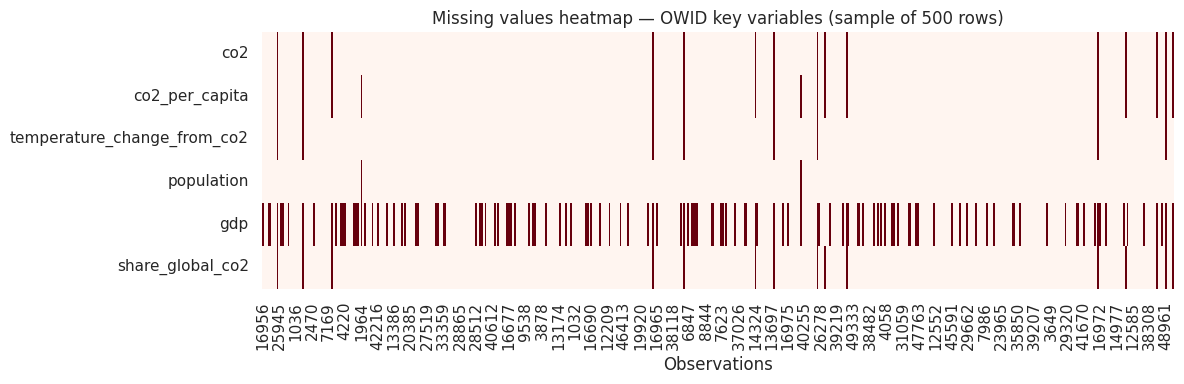

In [16]:
# ── Missing data heatmap for OWID key variables ──────────────────────────────
owid_sample = owid_clean[key_cols_present + ['Year', 'Entity', 'region']].sample(
    min(500, len(owid_clean)), random_state=42
)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(
    owid_sample[key_cols_present].isnull().T,
    cmap='Reds', cbar=False, ax=ax,
    yticklabels=key_cols_present
)
ax.set_title('Missing values heatmap — OWID key variables (sample of 500 rows)', fontsize=12)
ax.set_xlabel('Observations')
plt.tight_layout()
plt.show()

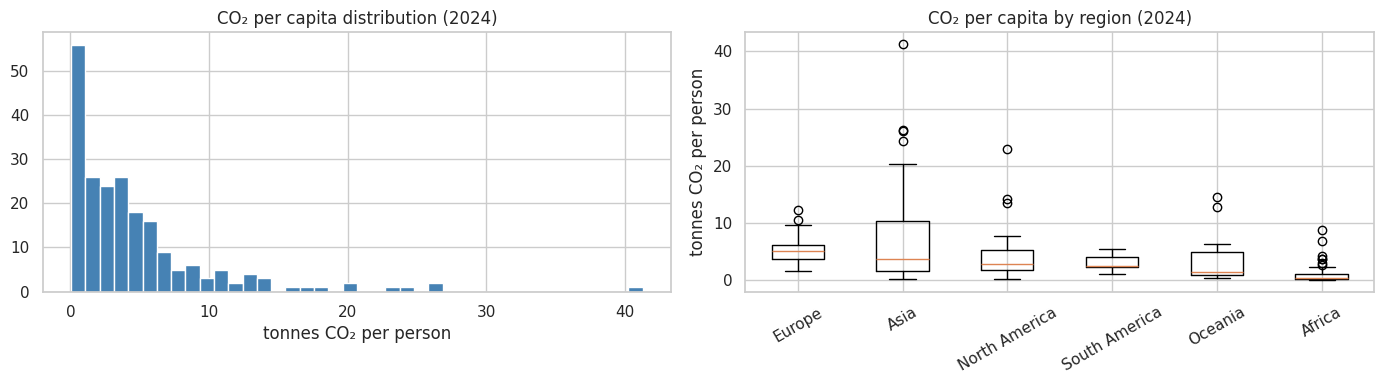

In [17]:
# ── Distribution of CO₂ per capita (before vs after removing extreme outliers)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

latest_year = owid_clean['Year'].max()
latest_data = owid_clean[owid_clean['Year'] == latest_year].dropna(subset=['co2_per_capita'])

axes[0].hist(latest_data['co2_per_capita'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title(f'CO₂ per capita distribution ({latest_year})')
axes[0].set_xlabel('tonnes CO₂ per person')

# Boxplot per region
region_data = latest_data.dropna(subset=['region'])
region_order = region_data.groupby('region')['co2_per_capita'].median().sort_values(ascending=False).index
axes[1].boxplot(
    [region_data[region_data['region'] == r]['co2_per_capita'].values for r in region_order],
    labels=region_order, vert=True
)
axes[1].set_title(f'CO₂ per capita by region ({latest_year})')
axes[1].set_ylabel('tonnes CO₂ per person')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

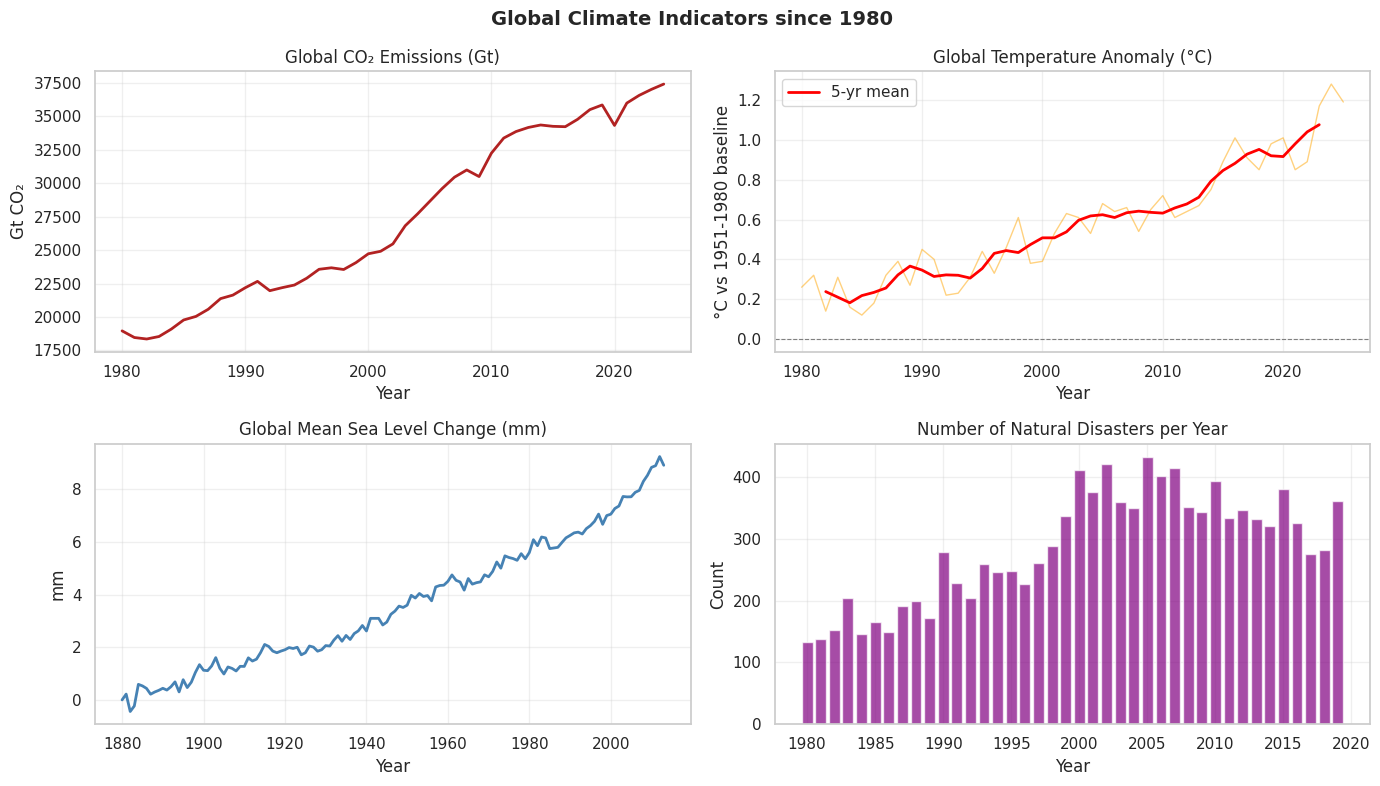

In [18]:
# ── Global trends overview (4-panel) ────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Global Climate Indicators since 1980', fontsize=14, fontweight='bold')

# 1. Global CO₂
axes[0,0].plot(global_df['Year'], global_df['global_co2'], color='firebrick', linewidth=2)
axes[0,0].set_title('Global CO₂ Emissions (Gt)')
axes[0,0].set_ylabel('Gt CO₂')

# 2. Temperature anomaly
axes[0,1].plot(nasa['Year'], nasa['temp_anomaly'], color='orange', alpha=0.5, linewidth=1)
axes[0,1].plot(nasa['Year'], nasa['temp_anomaly_5yr'], color='red', linewidth=2, label='5-yr mean')
axes[0,1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[0,1].set_title('Global Temperature Anomaly (°C)')
axes[0,1].set_ylabel('°C vs 1951-1980 baseline')
axes[0,1].legend()

# 3. Sea level
axes[1,0].plot(sea_clean['Year'], sea_clean['sea_level_mm'], color='steelblue', linewidth=2)
axes[1,0].set_title('Global Mean Sea Level Change (mm)')
axes[1,0].set_ylabel('mm')

# 4. Natural disasters
axes[1,1].bar(world_dis['Year'], world_dis['n_disasters'], color='purple', alpha=0.7)
axes[1,1].set_title('Number of Natural Disasters per Year')
axes[1,1].set_ylabel('Count')

for ax in axes.flat:
    ax.set_xlabel('Year')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Export Clean Datasets

In [19]:
# ── Save cleaned datasets for use in analysis notebook ───────────────────────
owid_clean.to_csv('/kaggle/working/owid_clean.csv', index=False)
nasa.to_csv('/kaggle/working/nasa_clean.csv', index=False)
sea_clean.to_csv('/kaggle/working/sea_clean.csv', index=False)
world_dis.to_csv('/kaggle/working/disasters_clean.csv', index=False)
global_df.to_csv('/kaggle/working/global_merged.csv', index=False)

print('All cleaned datasets saved to /kaggle/working/ ✓')
print(f'  owid_clean.csv       → {owid_clean.shape}')
print(f'  nasa_clean.csv       → {nasa.shape}')
print(f'  sea_clean.csv        → {sea_clean.shape}')
print(f'  disasters_clean.csv  → {world_dis.shape}')
print(f'  global_merged.csv    → {global_df.shape}')

All cleaned datasets saved to /kaggle/working/ ✓
  owid_clean.csv       → (9810, 20)
  nasa_clean.csv       → (46, 3)
  sea_clean.csv        → (134, 3)
  disasters_clean.csv  → (40, 2)
  global_merged.csv    → (146, 7)


## 10. Data Quality Summary

| Dataset | Source | Period | Key variables | Missing data notes |
|---|---|---|---|---|
| OWID CO₂ | Global Carbon Project / OWID | 1980–2022 | co2, co2_per_capita, gdp, population | GDP/energy missing for ~30% of developing countries |
| NASA GISS | NASA Goddard Institute | 1980–2023 | temp_anomaly | Complete, no missing values |
| EPA Sea Level | CSIRO + NOAA satellite | 1880–2013 | sea_level_mm | Complete for satellite era (1993+) |
| EMDAT Disasters | EM-DAT / OWID | 1980–2019 | n_disasters | World aggregate only in this version |

**Critical observations:**
- GDP and energy data are sparse for low-income countries — limits carbon intensity analysis for Africa
- Sea level data ends 2013 in this EPA version — adequate for trend analysis but not latest values
- Disaster data aggregated globally — per-country breakdown would strengthen regional analysis
- Temperature anomaly baseline is 1951–1980 (NASA standard)

In [20]:
import os
for f in os.listdir('/kaggle/working/'):
    print(f)

__notebook__.ipynb
global_merged.csv
sea_clean.csv
disasters_clean.csv
nasa_clean.csv
owid_clean.csv
